In [1]:
from ppg_basis import ppgGenerator
from ppg_basis import ppgExtractor
import matplotlib.pyplot as plt

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),Intel(R) Iris(R) Xe Graphics (RPL-U),IntegratedGPU,Vulkan,Mesa 25.2.1-arch1.4
❌,Mesa Intel(R) Iris(R) Xe Graphics (RPL-U),IntegratedGPU,OpenGL,4.6 (Core Profile) Mesa 25.2.1-arch1.4


/home/bai/Desktop/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: sigma parameter is invalid (0), defaulting to 0
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


Text(0.5, 1.0, 'Original PPG')

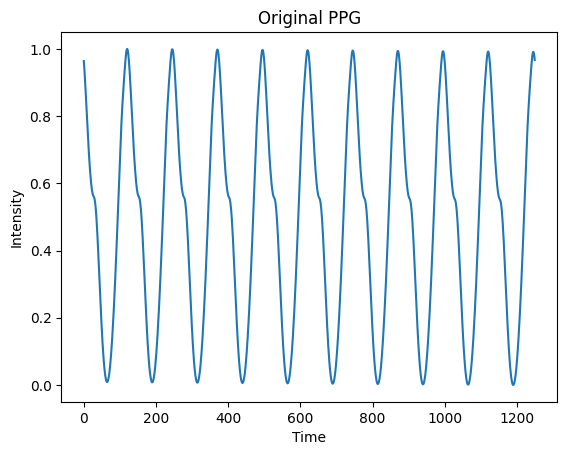

In [32]:
# Generate signal
ppgGen = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      solver="fft")

sig = ppgGen.generate_signal()
plt.plot(sig)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original PPG")

In [35]:
# Extract signal parameters
ppgExt = ppgExtractor(signal=sig,
                      fs=125,
                      hr=60,
                      sigma=0,
                      L=3,
                      basis_type='gamma',
                      solver="fft",
                     cost_metrics=["mse", "corr"])

views = ppgExt.plot_cost_landscape()

/home/bai/Desktop/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: sigma parameter is invalid (0), defaulting to 0
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


Basis 1/3


RFBOutputContext()

/home/bai/mabos/lib/python3.13/site-packages/pygfx/objects/_ruler.py:270: RuntimeWarning: divide by zero encountered in divide
  screen_full = (ndc_full[:, :2] / ndc_full[:, 3:4]) * half_canvas_size
/home/bai/mabos/lib/python3.13/site-packages/pygfx/objects/_ruler.py:270: RuntimeWarning: invalid value encountered in divide
  screen_full = (ndc_full[:, :2] / ndc_full[:, 3:4]) * half_canvas_size
/home/bai/mabos/lib/python3.13/site-packages/pygfx/objects/_ruler.py:282: RuntimeWarning: invalid value encountered in divide
  screen_sel = (ndc_sel[:, :2] / ndc_sel[:, 3:4]) * half_canvas_size
/home/bai/mabos/lib/python3.13/site-packages/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


Basis 2/3


RFBOutputContext()

Basis 3/3


RFBOutputContext()

In [36]:
for v in views:
    display(v)

In [37]:
ppgExt.cost_metrics = ["mse", "corr"]
theta_pred, params_pred = ppgExt.extract_ppg(block_update=True, 
                                             coord_cycles=4)

/home/bai/Desktop/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: sigma parameter is invalid (0), defaulting to 0
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


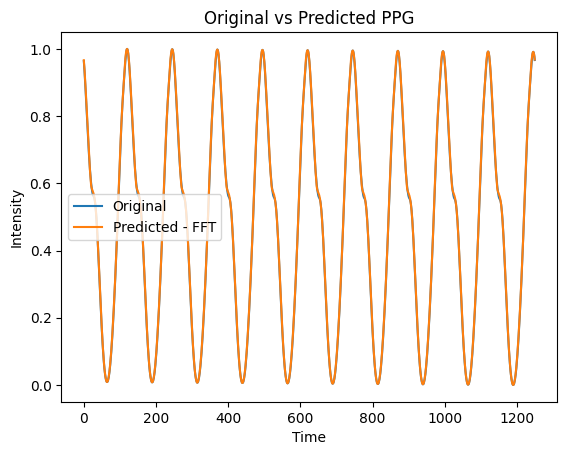

In [38]:
# Generate PPG using extracted parameters
ppgPrd = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      thetas=theta_pred,
                      params=params_pred,
                      solver="fft")
pred = ppgPrd.generate_signal()

plt.plot(sig)
plt.plot(pred)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original vs Predicted PPG")
plt.legend(["Original", "Predicted - FFT"])